<a href="https://colab.research.google.com/github/sissi820li/APS360/blob/main/MisinformationDetectionProject/MisinformationDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build and Define LSTM Architecture


In [9]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [ ]:
class MisinfoLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1, n_layers=1, bidirectional=True):
        super().__init__()
        self.name = "MisinfoLSTM"
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # LSTM Network: Captures the sequence of the text
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=bidirectional, 
                            batch_first=True)
        
        # Takes the LSTM memory and maps it to an output
        linear_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(linear_input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        lstm_out, (hidden, cell) = self.lstm(embedded)
    
        if self.lstm.bidirectional:
            hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden_final = hidden[-1,:,:]

        dense_outputs = self.fc(hidden_final)
        
        return self.sigmoid(dense_outputs).squeeze()

def get_model_name(name, batch_size, learning_rate, epoch):
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

Helper Functions and Training

In [ ]:
def evaluate(net, loader, criterion):
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    
    with torch.no_grad():
        for i, data in enumerate(loader, 0):
            inputs, labels = data
            
            labels = labels.float() 
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            predicted = torch.round(outputs)
            
            corr = predicted != labels
            total_err += int(corr.sum())
            total_loss += loss.item()
            total_epoch += len(labels)
            
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

def train_net(net, train_loader, val_loader, batch_size=32, learning_rate=0.001, num_epochs=10):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    start_time = time.time()
    for epoch in range(num_epochs): 
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            
            # Convert labels to float
            labels = labels.float()
            
            optimizer.zero_grad()
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # Calculate the statistics using rounding for binary outputs
            predicted = torch.round(outputs)
            corr = predicted != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
            
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        
        # Evaluate on the validation set
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        
        print(("Epoch {}: Train err: {:.4f}, Train loss: {:.4f} | "+
               "Validation err: {:.4f}, Validation loss: {:.4f}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        
        # Save current model to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
        
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)
    
    return model_path

In [3]:
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

Train and Evaluate the model

Epoch 1: Train err: 0.2924, Train loss: 0.5728 | Validation err: 0.2201, Validation loss: 0.4561
Epoch 2: Train err: 0.1114, Train loss: 0.2808 | Validation err: 0.1929, Validation loss: 0.4640
Epoch 3: Train err: 0.0335, Train loss: 0.0965 | Validation err: 0.2096, Validation loss: 0.6308
Epoch 4: Train err: 0.0130, Train loss: 0.0343 | Validation err: 0.2065, Validation loss: 0.8710
Epoch 5: Train err: 0.0049, Train loss: 0.0196 | Validation err: 0.2107, Validation loss: 0.9742
Epoch 6: Train err: 0.0027, Train loss: 0.0101 | Validation err: 0.2233, Validation loss: 1.1720
Epoch 7: Train err: 0.0009, Train loss: 0.0044 | Validation err: 0.2212, Validation loss: 1.1939
Epoch 8: Train err: 0.0004, Train loss: 0.0014 | Validation err: 0.2233, Validation loss: 1.3680
Epoch 9: Train err: 0.0004, Train loss: 0.0007 | Validation err: 0.2243, Validation loss: 1.4445
Epoch 10: Train err: 0.0002, Train loss: 0.0006 | Validation err: 0.2243, Validation loss: 1.5091
Epoch 11: Train err: 0.0002, 

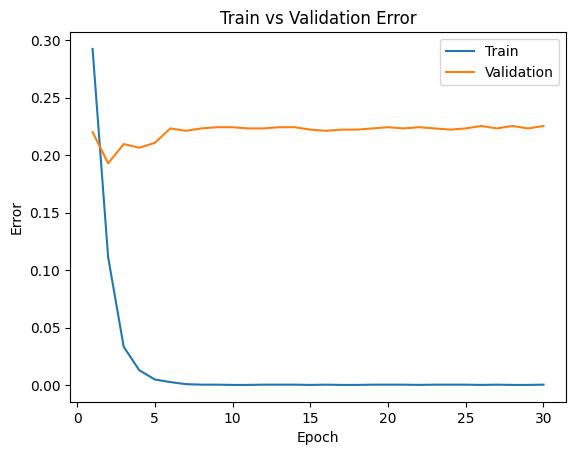

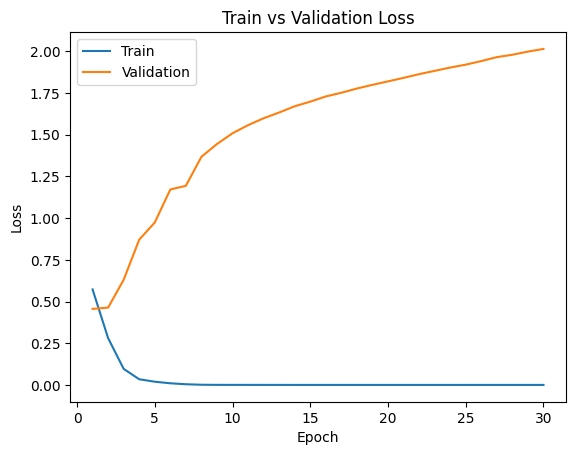

In [12]:
# Load the data
loaded_train = torch.load('dataset/dataset_tensors/dataset_split/train_tensors.pt')
train_dataset = TensorDataset(loaded_train['features'], loaded_train['labels'])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

loaded_val = torch.load('dataset/dataset_tensors/dataset_split/val_tensors.pt')
val_dataset = TensorDataset(loaded_val['features'], loaded_val['labels'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize model
# Find highest token ID in training and validation tensors
max_train_id = loaded_train['features'].max().item()
max_val_id = loaded_val['features'].max().item()

# The vocab size must be greater than highest token ID
VOCAB_SIZE = max(max_train_id, max_val_id) + 1 
EMBEDDING_DIM = 100
HIDDEN_DIM = 64

misinfo = MisinfoLSTM(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM, n_layers=2, bidirectional=True)

# Train and plot
model_path = train_net(misinfo, train_loader=train_loader, val_loader=val_loader, batch_size=32, learning_rate=0.01, num_epochs=30)
plot_training_curve(model_path)